In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy.spatial.distance import euclidean
import seaborn as sns

from datetime import datetime
from pathlib import Path

from aeon.distances import dtw_distance, msm_distance, euclidean_distance, wdtw_distance

palette = ["black", "#003DFD", "#b512b8", "#11a9ba", "#0d780f", "#f77f07", "#ba0f0f"]


class CFG:
    data_folder = Path.cwd().parent / "data"
    img_dim1 = 8
    img_dim2 = 4

In [ ]:
def load_m5_subset(data_folder: Path) -> pd.DataFrame:
    """
    Load and prepare the M5 subset data
    
    Parameters
    ----------
    data_folder : Path
        Path to the data directory
    
    Returns
    -------
    pd.DataFrame
        Processed DataFrame with proper date formatting and index
    """
    # Construct filepath
    filepath = data_folder / 'M5_t20_ABC.csv'
    
    # Verify file exists
    if not filepath.exists():
        raise FileNotFoundError(f"Data file not found at {filepath}")
        
    # Read data
    df = pd.read_csv(filepath, index_col=0)
    
    # Convert date to datetime
    df['date'] = pd.to_datetime(df['date'])
    
    # Remove last 28 days of each series
    df_sorted = df.sort_values(['item_id', 'date'])
    def remove_tail_values(group):
        return group.iloc[:-28]
    df = df_sorted.groupby('item_id').apply(remove_tail_values).reset_index(drop=True)
    
    # Add time-based features
    df['year'] = df['date'].dt.year
    df['month'] = df['date'].dt.month
    df['dayofweek'] = df['date'].dt.dayofweek
    df['quarter'] = df['date'].dt.quarter
    df['week_of_year'] = df['date'].dt.isocalendar().week
    
    return df


def analyze_dataset(df: pd.DataFrame) -> dict:
    """
    Analyze the dataset structure and provide summary statistics
    
    Parameters
    ----------
    df : pd.DataFrame
        Input DataFrame
    
    Returns
    -------
    dict
        Dictionary containing analysis results
    """
    # Get ABC distribution by unique products
    abc_dist = df.groupby('item_id')['ABC_class'].first().value_counts().to_dict()
    
    analysis = {
        'n_series': df['item_id'].nunique(),
       # 'n_stores': df['state_id'].nunique(),
        'departments':df['dept_id'].nunique(),
        ''
        'date_range': (df['date'].min(), df['date'].max()),
        'total_sales': df['sold'].sum(),
        'mean_price': df['sell_price'].mean(),
        'abc_distribution': abc_dist,
        'sales_by_class': df.groupby('ABC_class')['sold'].sum().to_dict(),
        'avg_price_by_class': df.groupby('ABC_class')['sell_price'].mean().to_dict()
    }
    
    return analysis


def plot_sales_analysis(series: pd.DataFrame, figsize=(15, 10)):
    """
    Create a comprehensive sales analysis plot
    
    Parameters
    ----------
    series : pd.DataFrame
        Single time series data to analyze
    figsize : tuple
        Figure size for the plots
    """
    fig, axes = plt.subplots(2, 1, figsize=figsize)
    
    # Sales over time
    axes[0].plot(series['date'], series['sold'], color = darts_colors[1], alpha=0.7)
    axes[0].set_title(f"Sales Over Time for {series['item_id'].iloc[0]}")
    axes[0].set_xlabel('Date')
    axes[0].set_ylabel('Units Sold')
    
    # Sales by day of week
    sns.boxplot(data=series, x='dayofweek', y='sold', ax=axes[1], color = darts_colors[2])
    axes[1].set_title('Sales Distribution by Day of Week')
    axes[1].set_xlabel('Day of Week')
    axes[1].set_ylabel('Units Sold')
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print(
        "\nSummary Statistics: "
        f"{series['sold'].describe()}"
    )

def plot_time_series(t, series_list, labels, title="Time Series Comparison"):
    """Plot multiple time series for comparison"""
    plt.figure(figsize=(10, 6))
    
    for i, series in enumerate(series_list):
        plt.plot(t, series, label=labels[i], color=palette[i % len(palette)])
    
    plt.title(title, fontsize=14)
    plt.xlabel("Time", fontsize=12)
    plt.ylabel("Value", fontsize=12)
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def calculate_distances(s1, s2):
    """Calculate various distance measures between two time series"""
    # Euclidean distance
    ed = euclidean_distance(s1, s2)
    
    # Dynamic Time Warping distance (no window constraint)
    dtw_dist = dtw_distance(s1, s2, window=None)
    
    # DTW with window constraint (Sakoe-Chiba band)
    # Window must be between 0 and 1 in aeon, representing the fraction of series length
    dtw_window1 = dtw_distance(s1, s2, window=0.05)  # 5% of series length
    dtw_window2 = dtw_distance(s1, s2, window=0.10)  # 10% of series length
    
    # Add weighted DTW for comparison
    wdtw_dist = wdtw_distance(s1, s2, g=0.1)  # g controls the penalty weight
    
    return {
        "Euclidean": ed,
        "DTW": dtw_dist,
        "DTW (window=5%)": dtw_window1,
        "DTW (window=10%)": dtw_window2,
        "WDTW": wdtw_dist
    }

def visualize_euclidean_matching(t, s1, s2, title="Euclidean Distance: Point-to-Point Alignment"):
    """Visualize how Euclidean distance aligns points at same time steps"""
    plt.figure(figsize=(12, 6))
    
    # Plot the two series
    plt.plot(t, s1, label="Series 1", color=palette[0])
    plt.plot(t, s2, label="Series 2", color=palette[1])
    
    # Draw lines between matching points (every 10th point for clarity)
    for i in range(0, len(t), 10):
        plt.plot([t[i], t[i]], [s1[i], s2[i]], 'k--', alpha=0.5)
        
    # Highlight a few matched points
    indices = [10, 30, 50, 70, 90]
    for i in indices:
        plt.scatter(t[i], s1[i], color='red', s=50, zorder=5)
        plt.scatter(t[i], s2[i], color='red', s=50, zorder=5)
    
    # Calculate and display the Euclidean distance
    ed = euclidean_distance(s1, s2)
    plt.text(0.02, 0.95, f"Euclidean Distance: {ed:.2f}", transform=plt.gca().transAxes, 
             bbox=dict(facecolor='white', alpha=0.8), fontsize=12)
    
    plt.title(title, fontsize=14)
    plt.xlabel("Time", fontsize=12)
    plt.ylabel("Value", fontsize=12)
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def visualize_dtw_matching(t, s1, s2, window=None, title="DTW: Optimal Path Alignment"):
    """Visualize how DTW aligns points across time using aeon"""
    # We need to compute DTW path ourselves since aeon doesn't expose alignment_path in the public API
    # First calculate the cost matrix and optimal path
    from scipy.spatial.distance import cdist
    
    # Create time point matrices
    s1_reshaped = s1.reshape(-1, 1)
    s2_reshaped = s2.reshape(-1, 1)
    
    # Calculate the cost matrix (pairwise Euclidean distances)
    cost_matrix = cdist(s1_reshaped, s2_reshaped, 'euclidean')
    
    # Initialize accumulated cost matrix
    acc_cost = np.zeros_like(cost_matrix)
    acc_cost[0, 0] = cost_matrix[0, 0]
    
    # Fill the first row and column
    for i in range(1, len(s1)):
        acc_cost[i, 0] = acc_cost[i-1, 0] + cost_matrix[i, 0]
    for j in range(1, len(s2)):
        acc_cost[0, j] = acc_cost[0, j-1] + cost_matrix[0, j]
    
    # Apply window constraint if specified
    if window is not None:
        # Convert window (fraction) to number of points
        if isinstance(window, float) and 0 <= window <= 1:
            window_size = int(window * len(s1))
        else:
            window_size = window
            
        for i in range(1, len(s1)):
            for j in range(1, len(s2)):
                if abs(i - j) <= window_size:
                    acc_cost[i, j] = cost_matrix[i, j] + min(
                        acc_cost[i-1, j],      # insertion
                        acc_cost[i, j-1],      # deletion
                        acc_cost[i-1, j-1]     # match
                    )
                else:
                    acc_cost[i, j] = np.inf
    else:
        for i in range(1, len(s1)):
            for j in range(1, len(s2)):
                acc_cost[i, j] = cost_matrix[i, j] + min(
                    acc_cost[i-1, j],      # insertion
                    acc_cost[i, j-1],      # deletion
                    acc_cost[i-1, j-1]     # match
                )
    
    # Backtrack to find the path
    path = []
    i, j = len(s1) - 1, len(s2) - 1
    path.append((i, j))
    
    while i > 0 or j > 0:
        if i == 0:
            j -= 1
        elif j == 0:
            i -= 1
        else:
            argmin = np.argmin([acc_cost[i-1, j], acc_cost[i, j-1], acc_cost[i-1, j-1]])
            if argmin == 0:
                i -= 1
            elif argmin == 1:
                j -= 1
            else:
                i -= 1
                j -= 1
        path.append((i, j))
    
    path.reverse()
    alignment_pairs = path
    
    plt.figure(figsize=(12, 6))
    
    # Plot the two series
    plt.plot(t, s1, label="Series 1", color=palette[0])
    plt.plot(t, s2, label="Series 2", color=palette[1])
    
    # Draw lines between matching points along the DTW path
    # Use only a subset of the path for visualization clarity
    viz_path = alignment_pairs[::max(1, len(alignment_pairs)//15)]  # Sample points for clearer visualization
    
    for i, j in viz_path:
        plt.plot([t[i], t[j]], [s1[i], s2[j]], 'k--', alpha=0.5)
        
    # Highlight a few matched points
    highlight_indices = viz_path[1:-1:2]  # Skip first and last, take every 2nd
    for i, j in highlight_indices:
        plt.scatter(t[i], s1[i], color='red', s=50, zorder=5)
        plt.scatter(t[j], s2[j], color='red', s=50, zorder=5)
    
    # Calculate and display the DTW distance
    if window is not None:
        # Need to convert window to fraction for aeon
        if not isinstance(window, float) or window > 1:
            window_frac = min(1.0, window / len(s1))
        else:
            window_frac = window
        dtw_dist = dtw_distance(s1, s2, window=window_frac)
    else:
        dtw_dist = dtw_distance(s1, s2, window=None)
        
    plt.text(0.02, 0.95, f"DTW Distance: {dtw_dist:.2f}", transform=plt.gca().transAxes, 
             bbox=dict(facecolor='white', alpha=0.8), fontsize=12)
    
    if window is not None:
        if isinstance(window, float) and window <= 1:
            title = f"{title} (Window={window*100:.0f}%)"
        else:
            title = f"{title} (Window={window} points)"
    
    plt.title(title, fontsize=14)
    plt.xlabel("Time", fontsize=12)
    plt.ylabel("Value", fontsize=12)
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def visualize_dtw_matrix(s1, s2, window=None, title="DTW Accumulated Cost Matrix"):
    """Visualize the DTW cost matrix and optimal path using numpy and scipy"""
    from scipy.spatial.distance import cdist
    
    # Create the cost matrix manually since we don't have access to aeon's internal functions
    s1_reshaped = s1.reshape(-1, 1)
    s2_reshaped = s2.reshape(-1, 1)
    
    # Calculate the cost matrix (pairwise Euclidean distances)
    cost_matrix = cdist(s1_reshaped, s2_reshaped, 'euclidean')
    
    # Initialize accumulated cost matrix
    acc_cost = np.zeros_like(cost_matrix)
    acc_cost[0, 0] = cost_matrix[0, 0]
    
    # Fill the first row and column
    for i in range(1, len(s1)):
        acc_cost[i, 0] = acc_cost[i-1, 0] + cost_matrix[i, 0]
    for j in range(1, len(s2)):
        acc_cost[0, j] = acc_cost[0, j-1] + cost_matrix[0, j]
    
    # Apply window constraint if specified
    if window is not None:
        # Convert window (fraction) to number of points
        if isinstance(window, float) and 0 <= window <= 1:
            window_size = int(window * len(s1))
        else:
            window_size = window
            
        for i in range(1, len(s1)):
            for j in range(1, len(s2)):
                if abs(i - j) <= window_size:
                    acc_cost[i, j] = cost_matrix[i, j] + min(
                        acc_cost[i-1, j],      # insertion
                        acc_cost[i, j-1],      # deletion
                        acc_cost[i-1, j-1]     # match
                    )
                else:
                    acc_cost[i, j] = np.inf
    else:
        for i in range(1, len(s1)):
            for j in range(1, len(s2)):
                acc_cost[i, j] = cost_matrix[i, j] + min(
                    acc_cost[i-1, j],      # insertion
                    acc_cost[i, j-1],      # deletion
                    acc_cost[i-1, j-1]     # match
                )
    
    # Backtrack to find the path
    path = []
    i, j = len(s1) - 1, len(s2) - 1
    path.append((i, j))
    
    while i > 0 or j > 0:
        if i == 0:
            j -= 1
        elif j == 0:
            i -= 1
        else:
            argmin = np.argmin([acc_cost[i-1, j], acc_cost[i, j-1], acc_cost[i-1, j-1]])
            if argmin == 0:
                i -= 1
            elif argmin == 1:
                j -= 1
            else:
                i -= 1
                j -= 1
        path.append((i, j))
    
    path.reverse()
    
    # Extract path coordinates
    path_y, path_x = zip(*path)
    
    plt.figure(figsize=(10, 8))
    
    # Create a custom colormap (blue to red)
    colors = [(0.0, palette[1]), (1.0, palette[6])]
    cm = LinearSegmentedColormap.from_list('custom_cmap', colors, N=100)
    
    # Make a copy of acc_cost for display (replace inf with max value)
    display_cost = acc_cost.copy()
    if window is not None:
        display_cost[display_cost == np.inf] = np.nanmax(display_cost[display_cost != np.inf])
    
    # Plot the accumulated cost matrix
    plt.imshow(display_cost, origin='lower', cmap=cm, aspect='auto')
    plt.colorbar(label='Accumulated Cost')
    
    # Plot the optimal warping path
    plt.plot(path_x, path_y, color='white', linewidth=2)
    
    # Calculate and display the DTW distance (the bottom-right value of cost matrix)
    # For window-constrained DTW, we should use aeon's function to get the true distance
    if window is not None:
        # Need to convert window to fraction for aeon
        if not isinstance(window, float) or window > 1:
            window_frac = min(1.0, window / len(s1))
        else:
            window_frac = window
        dtw_dist = dtw_distance(s1, s2, window=window_frac)
        
        if isinstance(window, float) and window <= 1:
            title = f"{title} (Window={window*100:.0f}%)"
        else:
            title = f"{title} (Window={window} points)"
    else:
        dtw_dist = dtw_distance(s1, s2, window=None)
    
    plt.text(0.02, 0.95, f"DTW Distance: {dtw_dist:.2f}", transform=plt.gca().transAxes, 
             bbox=dict(facecolor='white', alpha=0.8), fontsize=12)
    
    plt.title(title, fontsize=14)
    plt.xlabel("Series 2 Index", fontsize=12)
    plt.ylabel("Series 1 Index", fontsize=12)
    plt.tight_layout()
    plt.show()

def compare_distance_measures():
    """Run the complete demonstration of distance measures using aeon"""
    # Create example time series
    t, s1, s2, s3, s4, s5 = create_example_series()
    
    # 1. Visualize the different time series
    plot_time_series(
        t, 
        [s1, s2, s3, s4, s5], 
        ["Original", "Phase shifted", "Amplitude variation", "Different pattern", "Noisy signal"],
        "Sample Time Series for Distance Measure Comparison"
    )
    
    # 2. Euclidean vs DTW explanation
    # 2.1 Visualize Euclidean point-to-point matching
    visualize_euclidean_matching(t, s1, s2)
    
    # 2.2 Visualize DTW optimal alignment
    visualize_dtw_matching(t, s1, s2)
    
    # 3. DTW cost matrix and optimal path
    visualize_dtw_matrix(s1, s2)
    
    # 4. Impact of windowing constraint
    # Using window as percentage of series length (5%)
    window_size = int(0.05 * len(s1))
    visualize_dtw_matching(t, s1, s2, window=window_size)
    visualize_dtw_matrix(s1, s2, window=window_size)
    
    # 5. Compare actual distance values between original and each variant
    distances_table = []
    
    for i, s in enumerate([s2, s3, s4, s5]):
        name = ["Phase shifted", "Amplitude variation", "Different pattern", "Noisy signal"][i]
        distances = calculate_distances(s1, s)
        row = {"Series": name}
        row.update(distances)
        distances_table.append(row)
    
    df = pd.DataFrame(distances_table)
    print("\nDistance Comparison Table:")
    print(df.to_string(index=False))
    
    # Format as a bar chart for clearer comparison
    df_plot = df.set_index("Series")
    
    # Ensure we have enough colors for all distance measures
    bar_colors = palette[1:1+len(df_plot.columns)]
    
    ax = df_plot.plot(kind="bar", figsize=(14, 7), color=bar_colors)
    plt.title("Distance Measures Comparison", fontsize=14)
    plt.ylabel("Distance Value", fontsize=12)
    plt.legend(title="Distance Measure")
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # 7. Add a comparison of aeon's other distance measures
    # Calculate MSM (Move-Split-Merge) distance
    msm_distances = []
    for i, s in enumerate([s2, s3, s4, s5]):
        name = ["Phase shifted", "Amplitude variation", "Different pattern", "Noisy signal"][i]
        msm_dist = msm_distance(s1, s, c=1.0)  # c is the cost parameter
        msm_distances.append({"Series": name, "MSM": msm_dist})
    
    msm_df = pd.DataFrame(msm_distances)
    print("\nMove-Split-Merge Distance Comparison:")
    print(msm_df.to_string(index=False))
    
    return df

In [ ]:
t = np.linspace(0, 1, 100)
s1 = np.sin(2 * np.pi * t * 2)
s2 = np.sin(2 * np.pi * (t * 2 + 0.2))
s3 = 0.5 * np.sin(2 * np.pi * t * 2)
s4 = np.cos(2 * np.pi * t * 3)
s5 = np.sin(2 * np.pi * t * 2) + np.random.normal(0, 0.1, len(t))

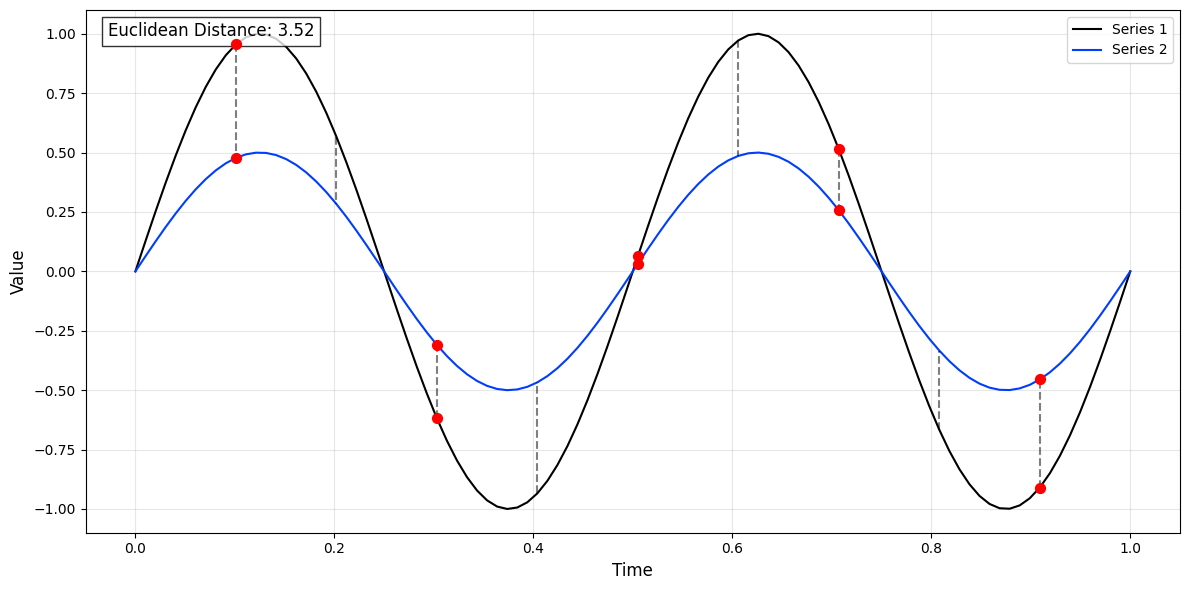

In [ ]:
visualize_euclidean_matching(t, s1, s3, title=None)

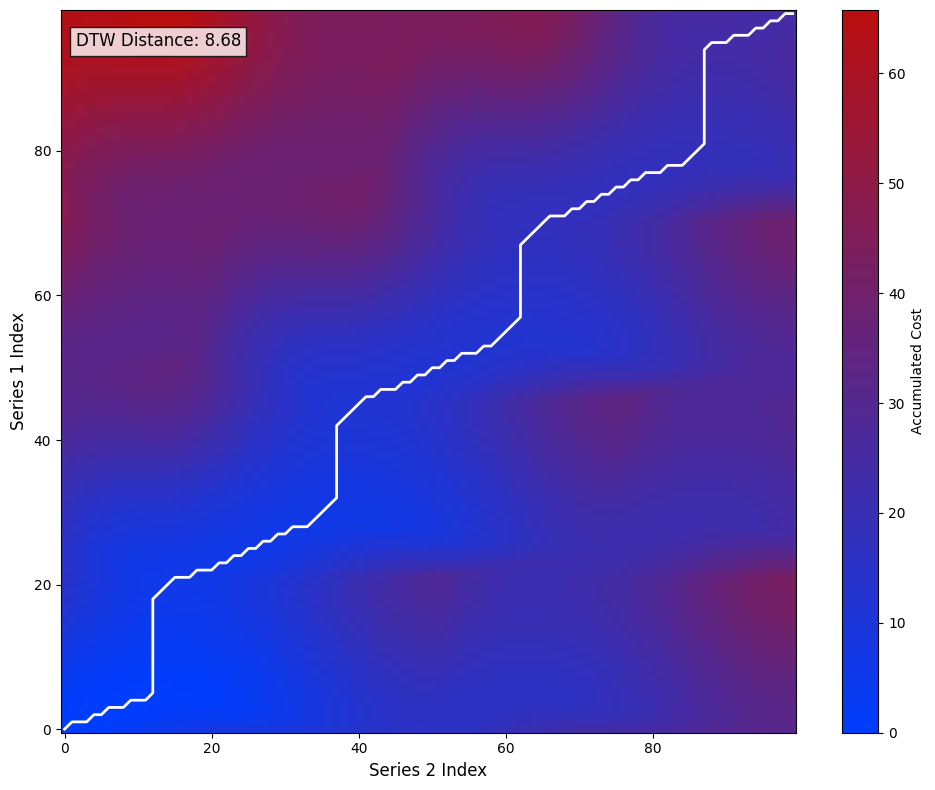

In [ ]:
visualize_dtw_matrix(s1, s3, title=None)

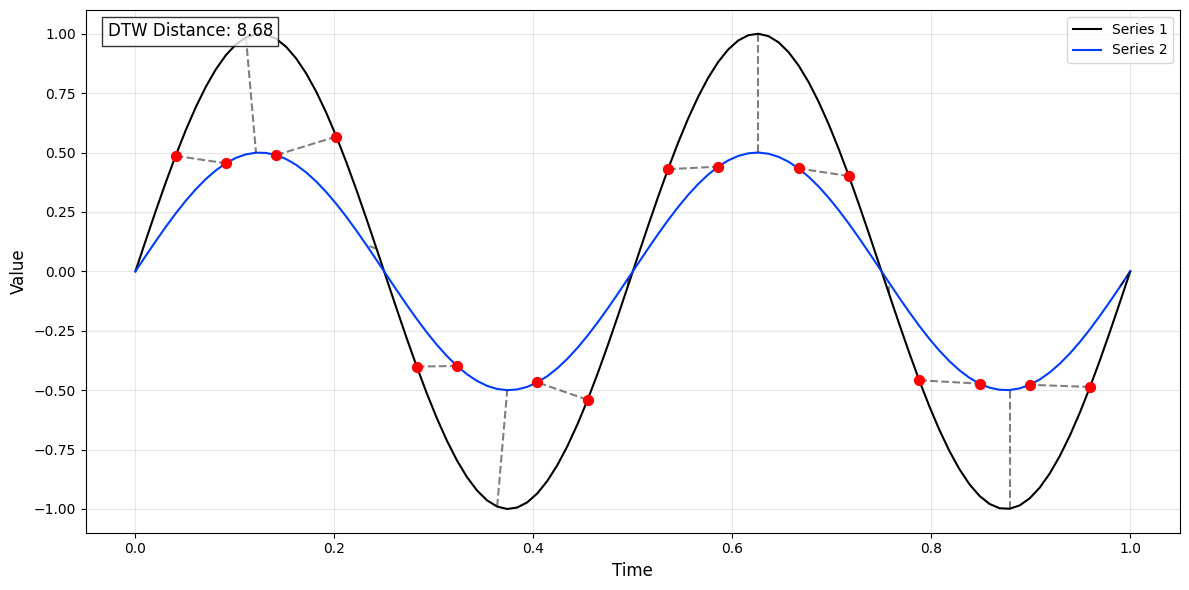

In [ ]:
visualize_dtw_matching(t, s1, s3, title=None)

In [ ]:
distances = calculate_distances(s1, s3)
distances

{'Euclidean': 3.517811819867572,
 'DTW': 8.683920276652852,
 'DTW (window=5%)': 8.73474444914017,
 'DTW (window=10%)': 8.683920276652852,
 'WDTW': 0.0690182068941828}

In [ ]:
# Load data
df = pd.read_csv('C:\\Users\\Graeme\\Documents\\github\\tsfwpt\\data\\dodgerloopday_imputed.csv')

# Split into train and test
train_df = df[df['source'] == 'train']
test_df = df[df['source'] == 'test']

print(df.head(n=3))

   series_id  class source  time  value  value_filled
0          0      1  train     1   12.0          12.0
1          0      1  train     2   18.0          18.0
2          0      1  train     3   11.0          11.0


In [ ]:
def prepare_data(df):
    series_list = []
    labels = []
    
    for series_id, group in df.groupby('series_id'):
        group = group.sort_values('time')
        series = group['value_filled'].values
        label = group['class'].iloc[0]
        series_list.append(series)
        labels.append(label)
    
    # Convert to numpy arrays
    X = np.array(series_list)
    y = np.array(labels)
    
    # Reshape for aeon (samples, dimensions, timepoints)
    X = X.reshape(X.shape[0], 1, X.shape[1])
    return X, y

X_train, y_train = prepare_data(train_df)
X_test, y_test = prepare_data(test_df)

In [ ]:
from aeon.classification.distance_based import KNeighborsTimeSeriesClassifier
from sklearn.metrics import accuracy_score, classification_report

# Create and train KNN classifiers with different distance measures
classifiers = {
    "Euclidean": KNeighborsTimeSeriesClassifier(n_neighbors=1, distance="euclidean"),
    "Manhattan": KNeighborsTimeSeriesClassifier(n_neighbors=1, distance="manhattan"),
    "Minkowski": KNeighborsTimeSeriesClassifier(n_neighbors=1, distance="minkowski"),
    "DTW": KNeighborsTimeSeriesClassifier(n_neighbors=1, distance="dtw"),
    "WDTW": KNeighborsTimeSeriesClassifier(n_neighbors=1, distance="wdtw"),
    "MSM": KNeighborsTimeSeriesClassifier(n_neighbors=1, distance="msm")
}

results = {}
for name, clf in classifiers.items():
    print(f"\nTraining {name} classifier...")
    clf.fit(X_train, y_train)
    
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = accuracy
    
    print(f"{name} Accuracy: {accuracy:.4f}")
    print(classification_report(y_test, y_pred))


Training Euclidean classifier...
Euclidean Accuracy: 0.5750
              precision    recall  f1-score   support

           1       0.92      1.00      0.96        12
           2       0.36      0.36      0.36        11
           3       0.67      0.20      0.31        10
           4       0.18      0.18      0.18        11
           5       0.44      0.58      0.50        12
           6       0.56      0.69      0.62        13
           7       1.00      0.91      0.95        11

    accuracy                           0.57        80
   macro avg       0.59      0.56      0.56        80
weighted avg       0.59      0.57      0.56        80


Training Manhattan classifier...
Manhattan Accuracy: 0.5750
              precision    recall  f1-score   support

           1       0.92      0.92      0.92        12
           2       0.36      0.36      0.36        11
           3       0.67      0.20      0.31        10
           4       0.30      0.27      0.29        11
          

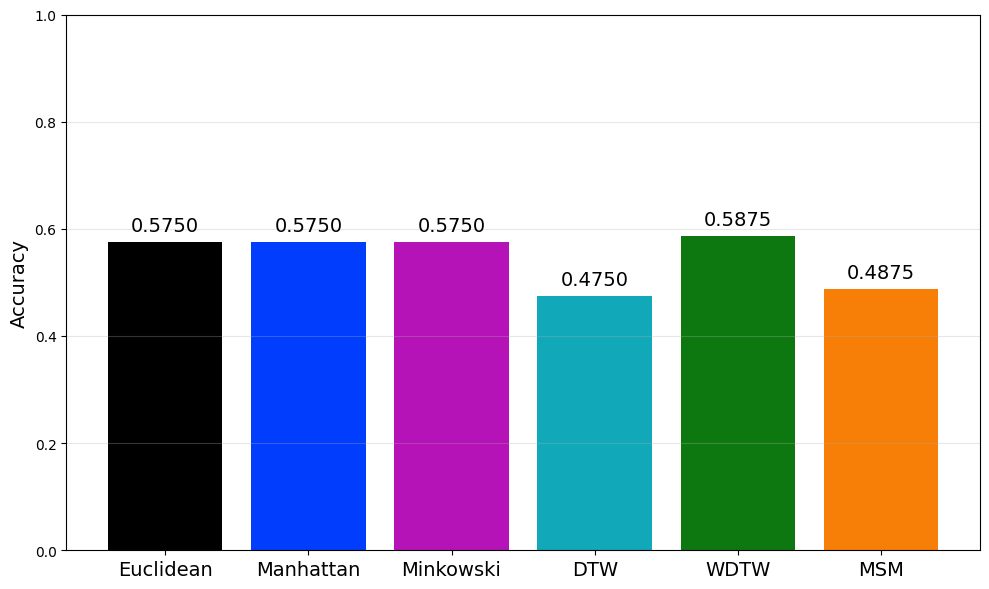

In [ ]:
# Plot accuracy comparison
plt.figure(figsize=(10, 6))
plt.bar(results.keys(), results.values(), color=palette[:len(results)])
plt.ylabel("Accuracy", fontsize=14)
plt.ylim(0, 1.0)
plt.grid(axis='y', alpha=0.3)

# Add values on top of bars
for i, (method, accuracy) in enumerate(results.items()):
    plt.text(i, accuracy + 0.02, f"{accuracy:.4f}", ha='center', fontsize=14)

plt.xticks(fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
from aeon.classification.distance_based import ElasticEnsemble
ee = ElasticEnsemble(
    distance_measures=["euclidean","wdtw","ddtw","msm", "twe"],
    proportion_of_param_options=0.1,
    proportion_train_in_param_finding=0.3,
    proportion_train_for_test=0.1,
)
ee.fit(X_train, y_train)
ee_preds = ee.predict(X_test)
results["ElasticEnsemble"] = accuracy_score(y_test, ee_preds)

c:\Users\Graeme\Documents\github\tsfwpt\.venv\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 1 is smaller than n_iter=10. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


In [ ]:
results["ProximityForest"]

KeyError: 'ProximityForest'

In [ ]:
results

{'Euclidean': 0.575,
 'Manhattan': 0.575,
 'Minkowski': 0.575,
 'DTW': 0.475,
 'WDTW': 0.5875,
 'MSM': 0.4875,
 'ElasticEnsemble': 0.575}

In [ ]:
from aeon.classification.distance_based import ProximityForest

forest = ProximityForest(n_trees=20, n_splitters=5, max_depth=10)
forest.fit(X_train, y_train)
forest_preds = forest.predict(X_test)

accuracy_score(y_test, forest_preds)
results["ProximityForest"] = accuracy_score(y_test, forest_preds)

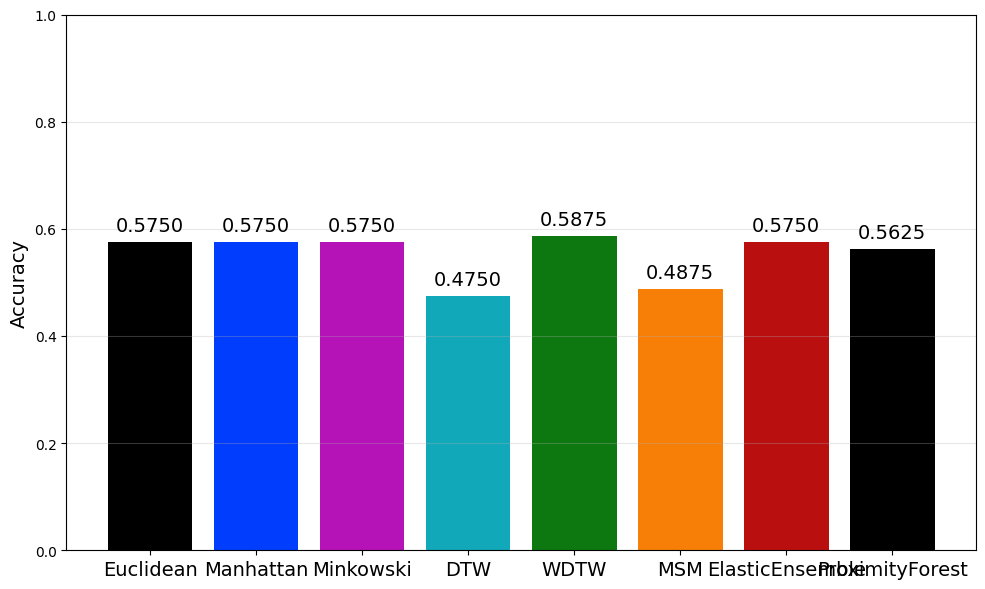

In [ ]:
# Plot accuracy comparison
plt.figure(figsize=(10, 6))
plt.bar(results.keys(), results.values(), color=palette[:len(results)])
plt.ylabel("Accuracy", fontsize=14)
plt.ylim(0, 1.0)
plt.grid(axis='y', alpha=0.3)

# Add values on top of bars
for i, (method, accuracy) in enumerate(results.items()):
    plt.text(i, accuracy + 0.02, f"{accuracy:.4f}", ha='center', fontsize=14)

plt.xticks(fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
import opunta

ModuleNotFoundError: No module named 'opunta'

In [ ]:
import optuna
from sklearn.metrics import accuracy_score

# Define the objective function for Optuna
def objective(trial):
    # Define the hyperparameters to optimize
    n_trees = trial.suggest_int('n_trees', 10, 200)
    n_splitters = trial.suggest_int('n_splitters', 2, 15)
    max_depth = trial.suggest_int('max_depth', 3, 20)
    
    # Create and train the model with the suggested hyperparameters
    forest = ProximityForest(
        n_trees=n_trees,
        n_splitters=n_splitters,
        max_depth=max_depth
    )
    
    forest.fit(X_train, y_train)
    predictions = forest.predict(X_test)
    accuracy = accuracy_score(y_test, predictions)
    
    return accuracy  # Optuna will maximize this value

# Create a study object and optimize the objective function
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)  # Adjust n_trials based on your time constraints

# Get the best parameters
best_params = study.best_params
print(f"Best parameters: {best_params}")
print(f"Best accuracy: {study.best_value:.4f}")

# Train the final model with the best parameters
best_forest = ProximityForest(
    n_trees=best_params['n_trees'],
    n_splitters=best_params['n_splitters'],
    max_depth=best_params['max_depth']
)

best_forest.fit(X_train, y_train)
best_predictions = best_forest.predict(X_test)
best_accuracy = accuracy_score(y_test, best_predictions)

# Add to your results dictionary
results["ProximityForest (tuned)"] = best_accuracy

# Visualize the optimization process
optuna.visualization.plot_optimization_history(study)
optuna.visualization.plot_param_importances(study)

[I 2025-04-12 17:29:35,178] A new study created in memory with name: no-name-45ab3fb4-371c-43a4-956c-1be2692ccdda
[W 2025-04-12 17:43:11,650] Trial 0 failed with parameters: {'n_trees': 116, 'n_splitters': 13, 'max_depth': 12} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "c:\Users\Graeme\Documents\github\tsfwpt\.venv\Lib\site-packages\optuna\study\_optimize.py", line 196, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "<ipython-input-18-97c7dc38cbb3>", line 18, in objective
    forest.fit(X_train, y_train)
  File "c:\Users\Graeme\Documents\github\tsfwpt\.venv\Lib\site-packages\aeon\classification\base.py", line 114, in fit
    self._fit(X, y)
  File "c:\Users\Graeme\Documents\github\tsfwpt\.venv\Lib\site-packages\aeon\classification\distance_based\_proximity_forest.py", line 109, in _fit
    self.trees_ = Parallel(
                  ^^^^^^^^^
  File "c:\Users\Graeme\Documents\github\tsfwpt\.venv

KeyboardInterrupt: 

In [ ]:
import optuna


# Define the objective function for Optuna
def objective(trial):
    # Define the hyperparameters to optimize
    n_trees = trial.suggest_int('n_trees', 10, 200)
    n_splitters = trial.suggest_int('n_splitters', 2, 15)
    max_depth = trial.suggest_int('max_depth', 3, 20)
    
    # Create and train the model with the suggested hyperparameters
    forest = ProximityForest(
        n_trees=n_trees,
        n_splitters=n_splitters,
        max_depth=max_depth
    )
    
    forest.fit(X_train, y_train)
    predictions = forest.predict(X_test)
    accuracy = accuracy_score(y_test, predictions)
    
    return accuracy  # Optuna will maximize this value

# Create a study object and optimize the objective function
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20)  

# Get the best parameters
best_params = study.best_params
print(f"Best parameters: {best_params}")
print(f"Best accuracy: {study.best_value:.4f}")

# Train the final model with the best parameters
best_forest = ProximityForest(
    n_trees=best_params['n_trees'],
    n_splitters=best_params['n_splitters'],
    max_depth=best_params['max_depth']
)

best_forest.fit(X_train, y_train)
best_predictions = best_forest.predict(X_test)
best_accuracy = accuracy_score(y_test, best_predictions)

# Add to your results dictionary
results["ProximityForest (tuned)"] = best_accuracy

# Visualize the optimization process
optuna.visualization.plot_optimization_history(study)
optuna.visualization.plot_param_importances(study)

[I 2025-04-12 17:44:49,560] A new study created in memory with name: no-name-f9101a94-334b-4a5a-8e5e-b181cc48a20e
[I 2025-04-12 17:50:23,636] Trial 0 finished with value: 0.6625 and parameters: {'n_trees': 54, 'n_splitters': 7, 'max_depth': 16}. Best is trial 0 with value: 0.6625.
[I 2025-04-12 18:11:51,917] Trial 1 finished with value: 0.65 and parameters: {'n_trees': 139, 'n_splitters': 13, 'max_depth': 7}. Best is trial 0 with value: 0.6625.
[I 2025-04-12 18:22:18,367] Trial 2 finished with value: 0.6 and parameters: {'n_trees': 127, 'n_splitters': 7, 'max_depth': 13}. Best is trial 0 with value: 0.6625.
[I 2025-04-12 18:25:47,620] Trial 3 finished with value: 0.6 and parameters: {'n_trees': 24, 'n_splitters': 15, 'max_depth': 10}. Best is trial 0 with value: 0.6625.
[I 2025-04-12 18:28:20,720] Trial 4 finished with value: 0.6375 and parameters: {'n_trees': 25, 'n_splitters': 9, 'max_depth': 5}. Best is trial 0 with value: 0.6625.
[I 2025-04-12 18:38:43,717] Trial 5 finished with va

Best parameters: {'n_trees': 104, 'n_splitters': 7, 'max_depth': 13}
Best accuracy: 0.6875


ImportError: Tried to import 'plotly' but failed. Please make sure that the package is installed correctly to use this feature. Actual error: No module named 'plotly'.

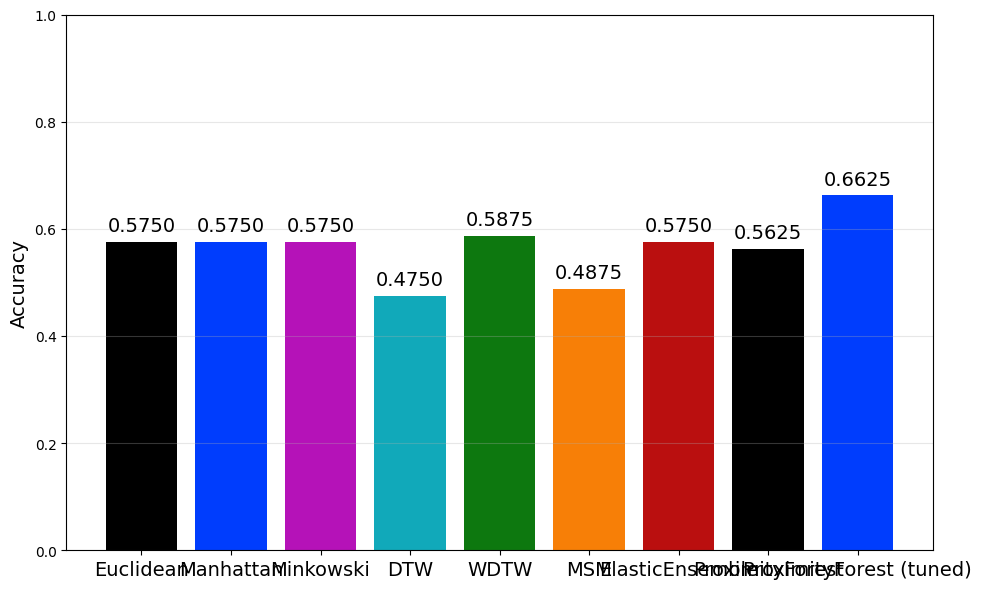

In [ ]:
# Plot accuracy comparison
plt.figure(figsize=(10, 6))
plt.bar(results.keys(), results.values(), color=palette[:len(results)])
plt.ylabel("Accuracy", fontsize=14)
plt.ylim(0, 1.0)
plt.grid(axis='y', alpha=0.3)

# Add values on top of bars
for i, (method, accuracy) in enumerate(results.items()):
    plt.text(i, accuracy + 0.02, f"{accuracy:.4f}", ha='center', fontsize=14)

plt.xticks(fontsize=14)
plt.tight_layout()
plt.show()